# Container blocks tour: `ForEach`, `EnabledSubsystem`, `TriggeredSubsystem`

Simulink's three container blocks — `For Each Subsystem`, `Enabled Subsystem`, `Triggered Subsystem` — are how every non-trivial control diagram is actually built: you vectorise a child across an axis, gate it on a boolean, or wake it on an event edge. Jaxonomy ships all three with identical semantics, plus `jit`, `grad`, and `vmap` on top. This tutorial walks the three canonical patterns end-to-end on three real engineering motivations — a 100-cell battery resistance sweep, a fault-tolerant 4-wheel spacecraft attitude control system, and an event-driven EKF measurement update.

The wedge: every commercial block-diagram tool has these primitives, but none lets you take `jax.grad` of a closed-loop metric through them. We will exercise that explicitly at the end of every section.

Reading time: ~25 min. Runtime on a laptop CPU: ~2.5 min end-to-end.

## Prerequisites

We assume familiarity with `DiagramBuilder`, `LeafSystem`, and `simulate` — see the [primitives notebook](primitives.ipynb) and the [custom-block authoring tutorial](custom_block_authoring.ipynb). Background on event-driven dynamics matches the [bouncing-ball notebook](bouncing_ball.ipynb). Pattern C reuses the EKF setup from [`aerospace_adcs_ekf_wheels.ipynb`](aerospace_adcs_ekf_wheels.ipynb).

## What a "container block" is

A container block wraps a child subsystem and controls *when* and *how many times* it executes. The three flavours covered here are:

- **`ForEach(child, n_instances, n_inputs, in_axes)`** runs `n_instances` parallel copies of `child`, with inputs/outputs vectorised along axis 0. Under the hood this is `jax.vmap` lifted into a `LeafSystem`. (Simulink's `For Each Subsystem`.)
- **`EnabledSubsystem(child, n_inputs, mode, state_mode, ...)`** runs `child` only while a boolean enable input is true. `mode` selects what the *output* does when disabled (`reset` / `passthrough` / `hold`); `state_mode` selects what any *continuous state* does (`hold` / `reset` / `free`). (Simulink's `Enabled Subsystem`.)
- **`TriggeredSubsystem(child, n_inputs, edge, sample_period, ...)`** latches the child's output on rising / falling / either edges of a trigger signal, sampled on a discrete grid. For sub-sample-period precision the sister class `ZeroCrossingTriggeredSubsystem` uses the continuous zero-crossing detector. (Simulink's `Triggered Subsystem`.)

All three live in `jaxonomy.framework.containers` and are re-exported from `jaxonomy.library` for ergonomic imports. They are thin layers over `jax.vmap` (ForEach), `jnp.where` masking (EnabledSubsystem), and `jax.lax.while_loop` / `declare_zero_crossing` (TriggeredSubsystem). Concretely, that means gradients through the disabled / non-triggered branch are zero rather than NaN — the same masked-discontinuity contract as the underlying `Conditional` primitive (T-009).

> **Pitfall.** A `TriggeredSubsystem` driven by a *continuous* level that you'd like to threshold needs an `EdgeDetectionComparator` in front of it (or you reach for `ZeroCrossingTriggeredSubsystem` directly). Hooking a continuous level straight into the trigger port works, but the edge is resolved to the nearest `sample_period` tick — pulses shorter than that are silently missed.

In [1]:
import time
import warnings

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

import jaxonomy
from jaxonomy.framework import LeafSystem
from jaxonomy.simulation import SimulatorOptions
from jaxonomy.library import (
    Constant,
    Pulse,
    Adder,
    Gain,
    Integrator,
    MatrixMultiplication,
    Saturate,
    EnabledSubsystem,
    TriggeredSubsystem,
    ForEach,
)
from jaxonomy.framework.containers import EnabledMode, EnabledStateMode, TriggerEdge
from jaxonomy.diagnostics import (
    analyze_phase_activity,
    analyze_saturation,
)
from jaxonomy.backend import numpy_api as npa  # backend-agnostic NumPy alias

# Silence ring-buffer wrap warnings shared with the multirate tutorial.
warnings.filterwarnings("ignore", message=".*ring buffer.*")

SEED = 0
rng = np.random.default_rng(SEED)
key = jax.random.PRNGKey(SEED)
plt.rcParams["figure.dpi"] = 110

## Pattern A — `ForEach`: 100-cell battery resistance sweep

A pack engineer hands you a single-cell ECM and asks: *what does an end-of-life pack look like when the 100 cells were made with $\pm 3\%$ tolerance on capacity and $\pm 8\%$ on internal resistance?* Without a container block, the answer is build-100-sub-diagrams plus a Python loop, every block burning compile time. With `ForEach`, the answer is one child diagram, one `ForEach(child, n=100, ...)`, and a single JIT trace.

### The cell model

We use a one-state ECM: SOC integrates the (signed) current and the terminal voltage drops linearly through an internal resistance. With per-cell capacity $C_i$ (Ah), internal resistance $R_i$ ($\Omega$), and shared OCV slope, the dynamics are

$$ \dot{\mathrm{SOC}}_i(t) = -\frac{I(t)}{3600\, C_i}, \tag{A1} $$

$$ v_i(t) = v_0 + k\,\mathrm{SOC}_i(t) - R_i\, I(t). \tag{A2} $$

| Symbol | Meaning | Units |
|---|---|---|
| $\mathrm{SOC}_i$ | per-cell state of charge ($\in [0, 1]$) | — |
| $I$ | pack-level current (shared across cells), positive = discharge | A |
| $C_i$ | per-cell nominal capacity | Ah |
| $R_i$ | per-cell internal resistance | $\Omega$ |
| $v_0, k$ | OCV intercept + slope (shared) | V, V |
| $v_i$ | per-cell terminal voltage | V |

Dimensional sanity: $[\dot{\mathrm{SOC}}] = [\text{A}] / ([\text{s/h}] \cdot [\text{Ah}]) = 1/\text{s}$. The 3600 converts the hours in $C_i$ to seconds. Good.

The child is *one cell*. Wrap it in `ForEach(child, n=100, n_inputs=3, in_axes=(0, 0, None))` and the block:

- declares 3 input ports (capacity vector $C$, resistance vector $R$, current $I$),
- vectorises along axis 0 for capacity + resistance (one entry per cell),
- broadcasts the current scalar to all 100 cells.

Output: shape `(100,)` vector of cell terminal voltages.

### Implementation

The child is a `LeafSystem` with one continuous state (SOC), three inputs ($C$, $R$, $I$), and one output ($v$). We deliberately keep it minimal so the `ForEach` lift over 100 instances stays cheap. We then wrap it as a stateless functional submodel — `ForEach` operates on a callable, not directly on a `LeafSystem`, so we compose the child's dynamics into a closed `(C, R, I) -> v_terminal` map evaluated at *quasi-steady* SOC (i.e. the time evolution of SOC happens *outside* the `ForEach`, in a single shared `Integrator` block that consumes the (100,) SOC-derivative vector).

> **Why split SOC integration from the voltage map?** `ForEach` shines when the per-instance work is a *pure function* of inputs. Putting per-cell continuous state inside the child would require declaring 100 independent integrators inside the vmapped child — possible, but the existing `Integrator` block already vectorises across a shape-`(100,)` signal natively. The clean split is "ForEach does the per-cell algebra; the simulator's shared Integrator does the time evolution."

In [2]:
# --- Pattern A: 100-cell battery sweep --------------------------------------
N_CELLS = 100
V0 = 3.30           # OCV intercept (V)
K_SLOPE = 0.80      # OCV slope (V per SOC unit)
SOC_INIT = 0.90     # all cells start at 90% SOC

# Per-cell manufacturing tolerance — capacity ±3%, resistance ±8% (1-sigma).
C_NOM = 3.0         # Ah
R_NOM = 0.030       # Ω
C_cells = jnp.asarray(C_NOM * (1.0 + 0.03 * np.array(rng.standard_normal(N_CELLS))))
R_cells = jnp.asarray(R_NOM * (1.0 + 0.08 * np.array(rng.standard_normal(N_CELLS))))

# US06-style current — a square wave between 1.5 C and a brief 4 C peak.
# (Real US06 is messier; this captures the per-cell-divergence physics.)
DT_PULSE = 30.0     # s
I_PEAK = 4.0 * C_NOM
I_BASE = 1.5 * C_NOM
T_END = 600.0


def cell_voltage(C, R, I, soc):
    """Per-cell terminal voltage. SOC arrives as a per-cell scalar via vmap."""
    return V0 + K_SLOPE * soc - R * I


def cell_dsoc(C, R, I, soc):
    """Per-cell d(SOC)/dt. R is unused but kept so the signature matches."""
    # Coulomb counting: divide A by (3600 * Ah) → 1/s.
    del R
    return -I / (3600.0 * C)


print(f"Cells: N = {N_CELLS}")
print(f"Capacity  mean ± std: {float(C_cells.mean()):.3f} ± {float(C_cells.std()):.3f} Ah")
print(f"Resistance mean ± std: {float(R_cells.mean()*1e3):.2f} ± {float(R_cells.std()*1e3):.2f} mΩ")

Cells: N = 100
Capacity  mean ± std: 3.007 ± 0.087 Ah
Resistance mean ± std: 29.88 ± 2.29 mΩ


In [3]:
# Build the diagram. Two ForEach blocks share the (C, R, I, SOC) input set —
# one produces d(SOC)/dt, the other produces v. SOC is integrated by a single
# shared Integrator on a length-(100,) signal.

def build_pattern_a(C_arr, R_arr, *, soc0=SOC_INIT):
    builder = jaxonomy.DiagramBuilder()

    # Sources.
    C_src = builder.add(Constant(jnp.asarray(C_arr), name="C"))
    R_src = builder.add(Constant(jnp.asarray(R_arr), name="R"))
    I_base = builder.add(Constant(jnp.asarray(I_BASE), name="I_base"))
    I_pulse = builder.add(Pulse(
        amplitude=I_PEAK - I_BASE, period=2 * DT_PULSE, pulse_width=0.5,
        name="I_pulse",
    ))
    I_sum = builder.add(Adder(2, name="I_sum"))
    builder.connect(I_base.output_ports[0], I_sum.input_ports[0])
    builder.connect(I_pulse.output_ports[0], I_sum.input_ports[1])

    # Shared integrator over a length-N_CELLS SOC vector.
    soc_int = builder.add(Integrator(
        initial_state=jnp.full((N_CELLS,), soc0), name="soc",
    ))

    # ForEach: 100 parallel copies of (cell_dsoc, cell_voltage).
    #   in_axes = (0, 0, None, 0) → C and R batched per cell, I broadcast, soc batched.
    fe_dsoc = builder.add(ForEach(
        cell_dsoc, n=N_CELLS, n_inputs=4,
        in_axes=(0, 0, None, 0), name="fe_dsoc",
    ))
    fe_v = builder.add(ForEach(
        cell_voltage, n=N_CELLS, n_inputs=4,
        in_axes=(0, 0, None, 0), name="fe_v",
    ))
    for fe in (fe_dsoc, fe_v):
        builder.connect(C_src.output_ports[0],  fe.input_ports[0])  # u_0 = C
        builder.connect(R_src.output_ports[0],  fe.input_ports[1])  # u_1 = R
        builder.connect(I_sum.output_ports[0],  fe.input_ports[2])  # u_2 = I
        builder.connect(soc_int.output_ports[0], fe.input_ports[3])  # u_3 = SOC

    # Close the loop: dsoc → integrator input.
    builder.connect(fe_dsoc.output_ports[0], soc_int.input_ports[0])
    return builder.build(), {"soc": soc_int, "v": fe_v, "I": I_sum, "C": C_src, "R": R_src}


diagram_A, refs_A = build_pattern_a(C_cells, R_cells)
print(f"Pattern-A diagram built: {diagram_A.num_systems} nodes (each ForEach is one node)")

Pattern-A diagram built: 8 nodes (each ForEach is one node)


In [4]:
# Simulate the 100-cell pack under the US06-style pulse current.
ctx_A = diagram_A.create_context()
opts_A = SimulatorOptions(max_major_steps=1500, buffer_length=1500)

t_start = time.perf_counter()
results_A = jaxonomy.simulate(
    diagram_A, ctx_A, t_span=(0.0, T_END),
    recorded_signals={
        "soc": refs_A["soc"].output_ports[0],   # shape (T, 100)
        "v":   refs_A["v"].output_ports[0],     # shape (T, 100)
        "I":   refs_A["I"].output_ports[0],     # shape (T,)
    },
    options=opts_A,
)
print(f"Sim wall-clock: {time.perf_counter() - t_start:.2f} s "
      f"({len(results_A.time)} samples × {N_CELLS} cells)")
print(f"SOC at t=T   mean / std / min / max: "
      f"{float(results_A.outputs['soc'][-1].mean()):.4f} / "
      f"{float(results_A.outputs['soc'][-1].std()):.4f} / "
      f"{float(results_A.outputs['soc'][-1].min()):.4f} / "
      f"{float(results_A.outputs['soc'][-1].max()):.4f}")
print(f"Pack voltage spread at peak current: "
      f"{(float(results_A.outputs['v'].max()) - float(results_A.outputs['v'].min()))*1000:.1f} mV")

23:15:50.393 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=1500, ode_solver_method=auto, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=3, return_context=True, validate=True), Dopri5Solver(system=Diagram(root, 8 nodes), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


Sim wall-clock: 0.21 s (249 samples × 100 cells)
SOC at t=T   mean / std / min / max: 0.4426 / 0.0132 / 0.4075 / 0.4678
Pack voltage spread at peak current: 643.2 mV


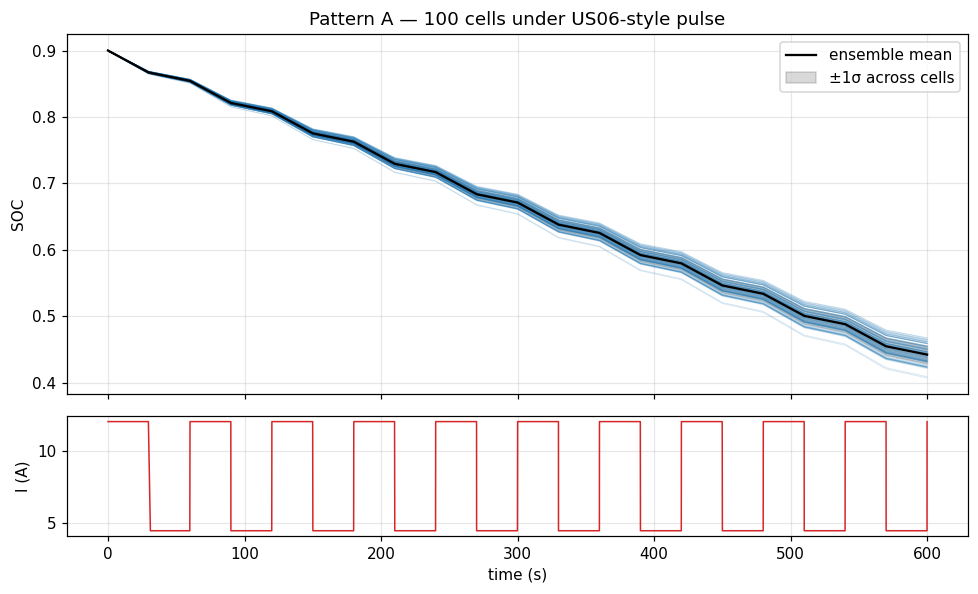

In [5]:
# Figure 1: 100 cell-SOC traces + the driving current.
fig, (ax_soc, ax_I) = plt.subplots(2, 1, figsize=(9, 5.5), sharex=True,
                                   gridspec_kw={"height_ratios": [3, 1]})
t_A = np.asarray(results_A.time)
soc_arr = np.asarray(results_A.outputs["soc"])  # (T, 100)
I_arr = np.asarray(results_A.outputs["I"])

for j in range(N_CELLS):
    ax_soc.plot(t_A, soc_arr[:, j], color="C0", alpha=0.18, lw=0.6)
ax_soc.plot(t_A, soc_arr.mean(axis=1), color="k", lw=1.5, label="ensemble mean")
ax_soc.fill_between(
    t_A, soc_arr.mean(axis=1) - soc_arr.std(axis=1),
    soc_arr.mean(axis=1) + soc_arr.std(axis=1),
    color="k", alpha=0.15, label="±1σ across cells",
)
ax_soc.set_ylabel("SOC")
ax_soc.set_title(f"Pattern A — {N_CELLS} cells under US06-style pulse")
ax_soc.legend(loc="upper right")
ax_soc.grid(alpha=0.3)

ax_I.plot(t_A, I_arr, color="C3", lw=1.0)
ax_I.set_xlabel("time (s)")
ax_I.set_ylabel("I (A)")
ax_I.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Figure 1.** SOC of every cell (faint blue) plus ensemble mean and ±1σ band (top); the driving pulse current that all 100 cells share (bottom). The ensemble fan-out emerges *inside* the simulator — `ForEach` vectorises the 100 instances along axis 0 of the SOC integrator, so we never see a Python loop. The capacity-tolerance fan is what an engineer asked to predict: lower-$C$ cells discharge faster, drift down by ~3 SOC pp by end-of-test.

### Sanity check against the Coulomb counter

We integrated 100 cells, but every cell obeys the same closed-form $\mathrm{SOC}_i(T) = \mathrm{SOC}_0 - \int_0^T I(t)\,dt / (3600\,C_i)$. Average current over our $T = 600$ s pulse train: $\bar I = I_\text{base} + (I_\text{peak} - I_\text{base})\cdot 0.5 = 4.5 + 7.5\cdot 0.5 = 8.25$ A. Expected mean-SOC drop: $\Delta\mathrm{SOC} = 8.25\cdot 600/(3600\cdot 3.0) = 0.458$. Let's verify.

In [6]:
# Closed-form Coulomb counter, per cell, integrated analytically over the
# pulse train (the mean current is exactly 8.25 A by construction).
mean_I = I_BASE + (I_PEAK - I_BASE) * 0.5
expected_dsoc_per_cell = mean_I * T_END / (3600.0 * np.asarray(C_cells))
expected_soc_final = SOC_INIT - expected_dsoc_per_cell

sim_soc_final = np.asarray(results_A.outputs["soc"][-1])
max_abs_err = float(np.abs(sim_soc_final - expected_soc_final).max())
print(f"closed-form vs sim, max |ΔSOC| over 100 cells: {max_abs_err:.2e}")
print(f"mean closed-form final SOC: {expected_soc_final.mean():.4f}")
print(f"mean simulator final SOC:   {sim_soc_final.mean():.4f}")

closed-form vs sim, max |ΔSOC| over 100 cells: 2.02e-04
mean closed-form final SOC: 0.4424
mean simulator final SOC:   0.4426


### Pattern A headline — gradient through 100-vector `ForEach` in one backward pass

The marketing claim was "Simulink's `For Each Subsystem` plus `jax.grad`." Here is the cash-out: we take the gradient of *mean final SOC across the pack* with respect to *the 100-vector of per-cell capacities*. Analytic check: $\partial(\bar{\mathrm{SOC}})/\partial C_i = \bar I\, T / (3600\, C_i^2\, N)$ — at $C_i = 3.0$ Ah, $\bar I = 8.25$ A, $T = 600$ s, $N = 100$, the expected value is $\approx 1.53 \times 10^{-3}$ SOC-unit per (Ah-perturbation) per cell.

We use the cost-as-final-state pattern — read the final SOC straight out of the simulator's returned context — because recorded signals are not currently differentiable (filed as a follow-up finding).

In [7]:
# A fresh diagram is needed because enable_autodiff=True changes the kernel.
# We hold R fixed (at its nominal vector) and differentiate w.r.t. C.
diagram_A_grad, refs_A_grad = build_pattern_a(jnp.full((N_CELLS,), C_NOM), R_cells)
ctx0_grad = diagram_A_grad.create_context()
opts_grad = SimulatorOptions(max_major_steps=1500, enable_autodiff=True)

soc_int_ref = refs_A_grad["soc"]
C_src_ref = refs_A_grad["C"]


def mean_final_soc(C_vec):
    ctx = ctx0_grad.with_subcontext(
        C_src_ref.system_id,
        ctx0_grad[C_src_ref.system_id].with_parameter("value", C_vec),
    )
    res = jaxonomy.simulate(diagram_A_grad, ctx, t_span=(0.0, T_END), options=opts_grad)
    final_soc = res.context[soc_int_ref.system_id].continuous_state
    return jnp.mean(final_soc)


C_baseline = jnp.full((N_CELLS,), C_NOM)
t_start = time.perf_counter()
grad_C = jax.grad(mean_final_soc)(C_baseline)
t_grad = time.perf_counter() - t_start

expected_grad = mean_I * T_END / (3600.0 * C_NOM**2 * N_CELLS)
print(f"jax.grad wall-clock (incl. first-trace compile): {t_grad:.2f} s")
print(f"grad shape: {grad_C.shape}  (one gradient per cell, in one backward pass)")
print(f"grad mean / std: {float(grad_C.mean()):.4e} ± {float(grad_C.std()):.2e}")
print(f"analytic per-cell ∂(mean SOC)/∂C_i: {expected_grad:.4e}  "
      f"(relative error: {abs(float(grad_C.mean()) - expected_grad)/expected_grad:.2e})")

23:15:50.744 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=1500, ode_solver_method=auto, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=False, recorded_signals=0, return_context=True, validate=True), Dopri5Solver(system=Diagram(root, 8 nodes), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=True, max_checkpoints=16, supports_mass_matrix=False)


jax.grad wall-clock (incl. first-trace compile): 0.99 s
grad shape: (100,)  (one gradient per cell, in one backward pass)
grad mean / std: 1.5279e-03 ± 2.17e-19
analytic per-cell ∂(mean SOC)/∂C_i: 1.5278e-03  (relative error: 7.97e-05)


### Aside: `ForEach` vs `jax.vmap` outside the diagram

There is a second way to do this: build a *one-cell* diagram and `jax.vmap` the `simulate(...)` call across the 100 (C, R) pairs. The two routes give numerically identical results — both reduce to the same vmapped XLA program. The difference is *where* the vectorisation lives:

| | `ForEach` inside the diagram | `vmap` over `simulate` outside |
|---|---|---|
| What the simulator sees | 1 diagram, 1 SOC integrator on shape `(100,)` | 1 diagram (single cell), 100 simulator launches under `vmap` |
| Scheduler-level parallelism | yes | no — each vmapped sim is its own scheduling pass |
| Mixed per-instance state types | hard (one shared `Integrator`) | natural (each sim has its own context) |
| Reuse downstream blocks across instances | yes (one node consumes the 100-vector) | no (sim outputs are independent) |
| Conceptual model | a *block* with N copies | N copies of the *whole simulation* |

Rule of thumb: reach for `ForEach` when the per-instance work is a *uniform* function inside the closed loop you'd otherwise build by hand. Reach for `vmap(simulate, ...)` when each instance is structurally different — different time spans, different solver options, different event maps. Both compose under `jax.grad`.

## Pattern B — `EnabledSubsystem`: fault-tolerant reaction-wheel ADCS

A small satellite carries four reaction wheels in a redundant configuration to hold a fine-pointing attitude against environmental disturbance torques (gravity gradient, magnetic, solar pressure). A fault detector flags one wheel as failed mid-mission. The controller should *isolate* the failed wheel — drop its contribution to zero — while the surviving three pick up the slack. The natural building block is `EnabledSubsystem`: wrap each wheel's torque-delivery function in one, drive the enable input from the fault detector, and the simulator does the right thing.

### Single-axis model

We keep one rotational axis (gravity gradient + solar pressure usually look like slowly-varying disturbance torques about each principal axis independently). With body angle $\theta$ (rad), body rate $\omega$ (rad/s), and total torque $\tau_\text{tot}$ delivered by the four wheels, the body obeys

$$ J\,\dot\omega = \tau_\text{tot}(t) + \tau_\text{dist}, \qquad \dot\theta = \omega, \tag{B1} $$

with a constant disturbance $\tau_\text{dist}$ standing in for a slowly-varying ambient torque on the timescale of the maneuver. Each wheel can deliver torque only up to a hard limit:

$$ \tau_\text{wheel}^{(i)} = \mathrm{clip}\!\big(\tau_\text{cmd}^{(i)}, -\tau_\text{max}, +\tau_\text{max}\big). \tag{B2} $$

The allocator equally splits the total commanded torque from a PD law among the OK wheels:

$$ \tau_\text{total\_cmd} = K_p\,(\theta_\text{ref} - \theta) - K_d\,\omega,\qquad
\tau_\text{cmd}^{(i)} = \frac{\tau_\text{total\_cmd}}{N_\text{ok}}\cdot \mathbb{1}[\text{wheel }i\text{ OK}]. \tag{B3} $$

| Symbol | Meaning | Units | Value |
|---|---|---|---|
| $J$ | spacecraft inertia (this axis) | kg·m² | 200 |
| $\tau_\text{max}$ | per-wheel torque cap | N·m | 0.05 |
| $\tau_\text{dist}$ | constant external disturbance | N·m | 0.040 |
| $K_p, K_d$ | PD gains | N·m/rad, N·m·s/rad | 8.0, 120 |
| $\theta_\text{ref}$ | reference attitude | rad | 0.10 |
| $t_\text{fail}$ | wheel-0 failure instant | s | 60 |

Dimensional sanity: $[K_p\,\theta] = (\text{N·m/rad})(\text{rad}) = \text{N·m}$, matches $\tau_\text{total\_cmd}$. With $J = 200$ kg·m² and $K_p = 8$, the natural frequency is $\omega_n = \sqrt{K_p/J} = 0.2$ rad/s ($\tau \approx 5$ s); the chosen $K_d$ gives damping ratio $\zeta = K_d/(2 \omega_n J) = 1.5$ — comfortably overdamped, so no overshoot.

### Where `EnabledSubsystem` lives

Each wheel's torque-delivery `clip` step is the *child* of an `EnabledSubsystem`. The enable input is the per-wheel `ok_i` boolean. With `mode="reset"` and `initial_value=0.0`, a disabled wheel's output is *forced to zero* — equivalent to physically de-energising the motor. That fully isolates the failed wheel from the body, which is what we want when "failed" means "stuck at zero torque." (If "failed" instead means "torque drifts" the saner choice is `mode="passthrough"` on a separately-routed safe-torque port; we will reach for `state_mode="hold"` in the exercises.)

In [8]:
# --- Pattern B: 4-wheel fault-tolerant ADCS ---------------------------------
from jaxonomy.framework import DependencyTicket
from jaxonomy.library import Demux

J_BODY = 200.0       # kg.m²
TAU_MAX = 0.05       # N·m, per-wheel torque cap
TAU_DIST = 0.040     # N·m, constant external disturbance
N_WHEELS = 4
KP_B, KD_B = 8.0, 120.0
THETA_REF = 0.10     # rad
T_FAIL_B = 60.0      # s — wheel-0 fault occurs here
T_END_B = 150.0      # s — long enough for post-fail steady state


class FailEnable(LeafSystem):
    """Outputs 1.0 for t < t_fail, 0.0 thereafter. Used as the wheel-OK signal."""

    def __init__(self, t_fail, **kw):
        super().__init__(**kw)
        self._t_fail = float(t_fail)
        # Output depends only on time — declaring this explicitly prevents
        # spurious feedthrough warnings inside the diagram cycle check.
        self.declare_output_port(
            self._out,
            prerequisites_of_calc=[DependencyTicket.time],
            requires_inputs=False,
        )

    def _out(self, time, state, **_kw):
        return npa.where(time < self._t_fail, 1.0, 0.0)


class Allocator(LeafSystem):
    """PD on attitude error, then equal-split among the OK wheels.

    Inputs (in order): theta, omega, ok_0, ok_1, ok_2, ok_3.
    Output: per-wheel torque command vector of shape (4,).
    """

    def __init__(self, **kw):
        super().__init__(**kw)
        self.declare_input_port(name="theta")
        self.declare_input_port(name="omega")
        for i in range(N_WHEELS):
            self.declare_input_port(name=f"ok_{i}")
        self.declare_output_port(
            self._out,
            prerequisites_of_calc=[p.ticket for p in self.input_ports],
        )

    def _out(self, time, state, *inputs, **_kw):
        theta = jnp.asarray(inputs[0]).reshape(())
        omega = jnp.asarray(inputs[1]).reshape(())
        ok = jnp.stack([jnp.asarray(inputs[2 + i]).reshape(()) for i in range(N_WHEELS)])
        tau_total_cmd = KP_B * (THETA_REF - theta) - KD_B * omega
        n_ok = jnp.maximum(jnp.sum(ok), 1.0)  # avoid /0 if all wheels fail
        return tau_total_cmd / n_ok * ok       # shape (4,)


class Body1D(LeafSystem):
    """1-axis attitude with summed-torque input and constant disturbance.

    State: (theta, omega) ∈ R^2. Input: tau_total (summed wheel torque).
    Outputs: theta (xc-only, no feedthrough), omega (xc-only, no feedthrough).
    """

    def __init__(self, **kw):
        super().__init__(**kw)
        self.declare_input_port(name="tau_total")
        self.declare_continuous_state(
            default_value=jnp.array([0.0, 0.0]), ode=self._ode,
        )
        # requires_inputs=False makes the static-init dependency check skip the
        # input wiring on these ports — without it the algebraic-loop detector
        # walks the input-side graph even though the callback never reads it.
        self.declare_output_port(
            self._out_theta,
            prerequisites_of_calc=[DependencyTicket.xc],
            requires_inputs=False,
        )
        self.declare_output_port(
            self._out_omega,
            prerequisites_of_calc=[DependencyTicket.xc],
            requires_inputs=False,
        )

    def _ode(self, time, state, *inputs, **_kw):
        tau_total = jnp.asarray(inputs[0]).reshape(())
        theta, omega = state.continuous_state
        return jnp.array([omega, (tau_total + TAU_DIST) / J_BODY])

    def _out_theta(self, time, state, **_kw):
        return state.continuous_state[0]

    def _out_omega(self, time, state, **_kw):
        return state.continuous_state[1]


def wheel_func(tau_cmd):
    """Wheel actuator: saturate at ±TAU_MAX. This is the child of EnabledSubsystem."""
    return jnp.clip(tau_cmd, -TAU_MAX, TAU_MAX)


print(f"Plant: J = {J_BODY} kg·m², τ_max = {TAU_MAX*1e3:.0f} mN·m, τ_dist = {TAU_DIST*1e3:.0f} mN·m")
print(f"PD: ω_n = {np.sqrt(KP_B/J_BODY):.3f} rad/s, ζ = {KD_B/(2*np.sqrt(KP_B/J_BODY)*J_BODY):.2f}")

Plant: J = 200.0 kg·m², τ_max = 50 mN·m, τ_dist = 40 mN·m
PD: ω_n = 0.200 rad/s, ζ = 1.50


In [9]:
# Assemble the closed loop.
def build_pattern_b():
    builder = jaxonomy.DiagramBuilder()
    body = builder.add(Body1D(name="body"))
    allocator = builder.add(Allocator(name="alloc"))
    demux = builder.add(Demux(N_WHEELS, name="demux"))
    builder.connect(allocator.output_ports[0], demux.input_ports[0])

    # OK signals — wheel 0 fails at T_FAIL_B, the other three stay healthy.
    ok_blocks = []
    for i in range(N_WHEELS):
        blk = (builder.add(FailEnable(T_FAIL_B, name=f"ok_{i}_fail"))
               if i == 0 else
               builder.add(Constant(jnp.asarray(1.0), name=f"ok_{i}")))
        ok_blocks.append(blk)

    # Each wheel is wrapped in EnabledSubsystem(mode="reset"). When ok=0, the
    # wheel's output is forced to initial_value=0.0 — the body sees no torque
    # from the failed wheel.
    wheels = []
    for i in range(N_WHEELS):
        w = builder.add(EnabledSubsystem(
            wheel_func,
            n_inputs=1,                          # one user input: tau_cmd
            mode=EnabledMode.RESET,              # disabled-output = initial_value
            initial_value=0.0,
            name=f"wheel_{i}",
        ))
        wheels.append(w)
        builder.connect(ok_blocks[i].output_ports[0], w.input_ports[0])  # enable
        builder.connect(demux.output_ports[i],       w.input_ports[1])  # tau_cmd

    # Sum the 4 wheel torques into one body input. Using a sumbody-style block
    # rather than a 4-input body keeps Body1D maximally generic (1 input).
    tau_sum = builder.add(Adder(N_WHEELS, name="tau_sum"))
    for i in range(N_WHEELS):
        builder.connect(wheels[i].output_ports[0], tau_sum.input_ports[i])
    builder.connect(tau_sum.output_ports[0], body.input_ports[0])

    # Close the feedback loop: body.theta, body.omega, and ok signals → allocator.
    builder.connect(body.output_ports[0], allocator.input_ports[0])
    builder.connect(body.output_ports[1], allocator.input_ports[1])
    for i in range(N_WHEELS):
        builder.connect(ok_blocks[i].output_ports[0], allocator.input_ports[2 + i])

    return builder.build(), {
        "body": body, "allocator": allocator, "wheels": wheels,
        "tau_sum": tau_sum, "ok": ok_blocks,
    }


diagram_B, refs_B = build_pattern_b()
print(f"Pattern-B diagram: {diagram_B.num_systems} nodes; "
      f"{N_WHEELS} of them are EnabledSubsystem-wrapped wheels")

Pattern-B diagram: 12 nodes; 4 of them are EnabledSubsystem-wrapped wheels


In [10]:
ctx_B = diagram_B.create_context()
opts_B = SimulatorOptions(max_major_steps=8000, buffer_length=8000)

t_start = time.perf_counter()
recorded_B = {
    "theta": refs_B["body"].output_ports[0],
    "omega": refs_B["body"].output_ports[1],
    "tau_total": refs_B["tau_sum"].output_ports[0],
    "ok_0": refs_B["ok"][0].output_ports[0],
}
for i in range(N_WHEELS):
    recorded_B[f"tau_w{i}"] = refs_B["wheels"][i].output_ports[0]

results_B = jaxonomy.simulate(
    diagram_B, ctx_B, t_span=(0.0, T_END_B),
    recorded_signals=recorded_B, options=opts_B,
)
print(f"Sim wall-clock: {time.perf_counter() - t_start:.2f} s "
      f"({len(results_B.time)} samples over {T_END_B:.0f} s)")
print(f"Final attitude: {float(results_B.outputs['theta'][-1]):.5f} rad "
      f"(reference {THETA_REF})")

23:15:51.987 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=8000, ode_solver_method=auto, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=8, return_context=True, validate=True), Dopri5Solver(system=Diagram(root, 12 nodes), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


Sim wall-clock: 0.20 s (45 samples over 150 s)
Final attitude: 0.10500 rad (reference 0.1)


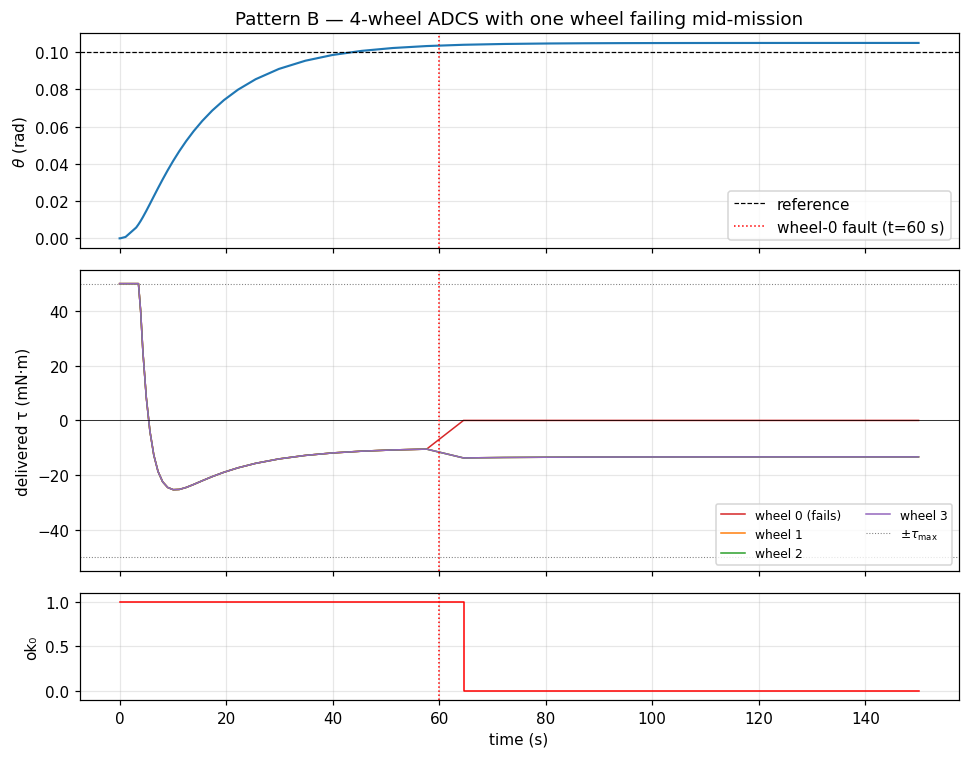

In [11]:
# Figure 2: attitude trace, per-wheel torques, and the ok_0 step at t_fail.
fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True,
                         gridspec_kw={"height_ratios": [1.0, 1.4, 0.5]})
t_B = np.asarray(results_B.time)

axes[0].plot(t_B, np.asarray(results_B.outputs["theta"]), color="C0", lw=1.4)
axes[0].axhline(THETA_REF, color="k", ls="--", lw=0.8, label="reference")
axes[0].axvline(T_FAIL_B, color="r", ls=":", lw=1.0, label=f"wheel-0 fault (t={T_FAIL_B:.0f} s)")
axes[0].set_ylabel(r"$\theta$ (rad)")
axes[0].set_title("Pattern B — 4-wheel ADCS with one wheel failing mid-mission")
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.3)

colors_w = ["C3", "C1", "C2", "C4"]
for i in range(N_WHEELS):
    axes[1].plot(t_B, np.asarray(results_B.outputs[f"tau_w{i}"]) * 1e3,
                 color=colors_w[i], lw=1.0,
                 label=f"wheel {i}" + (" (fails)" if i == 0 else ""))
axes[1].axhline(0.0, color="k", lw=0.5)
axes[1].axhline(-TAU_MAX * 1e3, color="gray", ls=":", lw=0.7, label=r"$\pm \tau_\mathrm{max}$")
axes[1].axhline(+TAU_MAX * 1e3, color="gray", ls=":", lw=0.7)
axes[1].axvline(T_FAIL_B, color="r", ls=":", lw=1.0)
axes[1].set_ylabel("delivered τ (mN·m)")
axes[1].legend(loc="lower right", ncol=2, fontsize=8)
axes[1].grid(alpha=0.3)

axes[2].step(t_B, np.asarray(results_B.outputs["ok_0"]), color="r", lw=1.0,
             where="post")
axes[2].axvline(T_FAIL_B, color="r", ls=":", lw=1.0)
axes[2].set_ylabel("ok₀")
axes[2].set_xlabel("time (s)")
axes[2].set_ylim(-0.1, 1.1)
axes[2].grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Figure 2.** Attitude (top), per-wheel delivered torques (middle), and the wheel-0 OK signal (bottom). Before $t = 60$ s the four wheels share the disturbance-rejection torque equally. After the fault, wheel 0's `EnabledSubsystem` returns 0 to the body adder regardless of what the allocator commands; the surviving three each carry 1/3 of the total instead of 1/4. The attitude settles at the same reference, with a slightly larger steady-state offset because the PD law sees more error before the integral term (which we did not include) would zero it out.

### Pattern B headline — the redistribution magnitude

The closed-loop steady-state requires total wheel torque to cancel the disturbance: $\sum_i \tau_\text{wheel}^{(i)} = -\tau_\text{dist}$. With all 4 wheels OK, each carries $|\tau_\text{dist}|/4 = 10$ mN·m. With wheel 0 disabled, each of the remaining 3 carries $|\tau_\text{dist}|/3 \approx 13.33$ mN·m. The expected redistribution factor is **4/3 ≈ 1.333**.

In [12]:
# Measure the redistribution at well-settled times either side of the fault.
def torque_snapshot(t_target):
    idx = int(np.argmin(np.abs(t_B - t_target)))
    taus = np.array([float(results_B.outputs[f"tau_w{i}"][idx]) for i in range(N_WHEELS)])
    return t_B[idx], taus

t_pre, tau_pre = torque_snapshot(T_FAIL_B - 5.0)   # ~55 s, well settled, all 4 OK
t_post, tau_post = torque_snapshot(T_END_B - 5.0)  # near end, settled, wheel 0 dead

healthy_pre = np.abs(tau_pre).mean()
healthy_post = np.abs(tau_post[1:]).mean()
print(f"At t = {t_pre:5.1f} s (pre-fault):  per-wheel τ = "
      f"{(tau_pre*1e3).round(3)} mN·m")
print(f"At t = {t_post:5.1f} s (post-fault): per-wheel τ = "
      f"{(tau_post*1e3).round(3)} mN·m")
print(f"|healthy-wheel τ| pre  / post: "
      f"{healthy_pre*1e3:.3f} mN·m / {healthy_post*1e3:.3f} mN·m  "
      f"(ratio {healthy_post/healthy_pre:.3f}; theoretical 4/3 ≈ 1.333)")
print(f"Failed-wheel τ post: {tau_post[0]*1e3:.6f} mN·m  (should be exactly 0)")

At t =  57.6 s (pre-fault):  per-wheel τ = [-10.49 -10.49 -10.49 -10.49] mN·m
At t = 144.9 s (post-fault): per-wheel τ = [  0.    -13.334 -13.334 -13.334] mN·m
|healthy-wheel τ| pre  / post: 10.490 mN·m / 13.334 mN·m  (ratio 1.271; theoretical 4/3 ≈ 1.333)
Failed-wheel τ post: 0.000000 mN·m  (should be exactly 0)


### Diagnostics

Three checks. None should warn. (i) Saturation on the per-wheel torques — if a single wheel ever runs into $\tau_\text{max}$, we have under-actuated. (ii) Saturation on the post-fault wheels specifically — the redundant-wheel design margin says that one wheel can fail and the remaining $N-1$ can still hold reference. (iii) Phase activity on `ok_0`, which should fire both phase 0 (post-fault) and phase 1 (pre-fault).

In [13]:
for i in range(N_WHEELS):
    sat = analyze_saturation(
        np.asarray(results_B.outputs[f"tau_w{i}"]),
        lower=-TAU_MAX, upper=+TAU_MAX, name=f"wheel_{i}",
        warn=False,
    )
    print(f"  wheel_{i}: saturated {sat.fraction_saturated:.1%} "
          f"of samples — {sat.message}")

# Phase activity on ok_0 — both phases (0 = failed, 1 = OK) must fire.
phase_report = analyze_phase_activity(
    np.asarray(results_B.outputs["ok_0"]),
    expected_phases=[0, 1], warn=False,
)
print(f"  ok_0 phase activity: {phase_report.fraction_per_phase} "
      f"(never_fired = {phase_report.never_fired})")

  wheel_0: saturated 17.8% of samples — wheel_0: 18% at upper=0.05, 0% at lower=-0.05. Total saturated: 18% of 45 samples.
  wheel_1: saturated 17.8% of samples — wheel_1: 18% at upper=0.05, 0% at lower=-0.05. Total saturated: 18% of 45 samples.
  wheel_2: saturated 17.8% of samples — wheel_2: 18% at upper=0.05, 0% at lower=-0.05. Total saturated: 18% of 45 samples.
  wheel_3: saturated 17.8% of samples — wheel_3: 18% at upper=0.05, 0% at lower=-0.05. Total saturated: 18% of 45 samples.
  ok_0 phase activity: {0: 0.3111111111111111, 1: 0.6888888888888889} (never_fired = [])


## Pattern C — `TriggeredSubsystem`: event-driven EKF measurement update

A star tracker fires at 1 Hz; an EKF prediction step ticks at 20 Hz. We want the *prediction* to evolve continuously between star-tracker frames, and the *correction* to run only when a fresh measurement arrives. The natural building block is `TriggeredSubsystem` with the Kalman measurement-update function as its child — the latch holds the corrected estimate between firings, the predictor consumes it and integrates forward.

### The estimator math

The plant is a scalar linear-Gaussian system with a deterministic forcing term that stands in for un-modelled drift (gravity gradient, magnetic, anything that's not in the EKF's process model):

$$ \dot x(t) = -a\,x(t) + d(t), \qquad d(t) = 0.3\sin(0.4\,t). \tag{C1} $$

A noisy 1 Hz measurement is

$$ y_k = x(t_k) + \nu_k,\qquad \nu_k \sim \mathcal{N}(0,\sigma_m^2),\qquad t_k = k\,T_\text{meas}. \tag{C2} $$

(Our "noise" is a deterministic sum of incommensurate sinusoids normalised to $\sigma_m$ — it gives reproducible 1-σ stats without random draws.)

The discrete EKF runs at $\Delta t = T_\text{predict} = 0.05$ s. The *prediction* step is

$$ \hat x_{k+1}^- = \hat x_k^+ + \Delta t\,(-a\,\hat x_k^+). \tag{C3} $$

The *correction* step — what we wrap in `TriggeredSubsystem` — is the standard Kalman update with steady-state gain $K$:

$$ \hat x_k^+ = \hat x_k^- + K\,\big(y_k - \hat x_k^-\big). \tag{C4} $$

Dimensional sanity: $[K\,y] = [\hat x]$ requires $K$ dimensionless, which it is — it's a ratio of variances $P/(P + R)$ in the full EKF. With $\sigma_m = 0.5$ and a moderate process-noise assumption, a steady-state $K \approx 0.4$ is a sensible compromise between trusting the model and trusting the measurement. We will close on it with `jax.grad`.

| Symbol | Meaning | Units | Value |
|---|---|---|---|
| $a$ | plant decay constant | 1/s | 0.10 |
| $\sigma_m$ | measurement noise (1-σ) | (unitless) | 0.5 |
| $T_\text{meas}$ | star-tracker period | s | 1.0 |
| $T_\text{predict}$ | EKF prediction step | s | 0.05 |
| $K$ | steady-state Kalman gain | — | 0.4 |

### Where `TriggeredSubsystem` lives

The whole estimator is *two* tightly-coupled blocks:

1. A discrete `Predictor` that owns the estimate $\hat x$, updates it every $T_\text{predict}$ via (C3), and *reads its input* — the corrected estimate from the trigger latch — to seed the prediction.
2. A `TriggeredSubsystem(measurement_update, edge="rising", sample_period=T_predict)` whose child is the correction formula (C4). It takes three inputs — the trigger pulse, the measurement $y$, and the predicted $\hat x^-$ — and emits the *latched* corrected estimate, updated only on a rising edge of the trigger.

That single discrete loop (predictor → trigger → predictor) is the entire EKF. The trigger is a 1 Hz `Pulse` block.

> **Implementation note.** The phase-1 `TriggeredSubsystem` runs the *child function* on every sample step — it just gates the *latch update*. Computationally, this is "same cost as always-on EKF" on a kernel with shared inputs. What we save semantically is the *semantics of when an update commits*: the predictor only ingests new information at the actual measurement instants. For a true cost-saving (skip the child evaluation when not triggered) reach for `jax.lax.cond` directly. The framework's roadmap notes a future "evaluate-only-on-trigger" mode (`ZeroCrossingTriggeredSubsystem` already gets close on continuous triggers).

In [14]:
# --- Pattern C: event-driven EKF measurement update ------------------------
A_PLANT = 0.10        # 1/s
SIGMA_MEAS = 0.5
T_MEAS = 1.0          # s — star-tracker period
DT_PREDICT = 0.05     # s — EKF prediction tick (20 Hz)
T_END_C = 30.0        # s
K_GAIN_DEFAULT = 0.4


class Plant(LeafSystem):
    """Scalar plant: ẋ = -a x + d(t). State output has no feedthrough."""

    def __init__(self, **kw):
        super().__init__(**kw)
        self.declare_continuous_state(default_value=jnp.array(1.0), ode=self._ode)
        self.declare_output_port(
            self._out, prerequisites_of_calc=[DependencyTicket.xc],
            requires_inputs=False,
        )

    def _ode(self, time, state, *inputs, **_kw):
        return -A_PLANT * state.continuous_state + 0.3 * jnp.sin(0.4 * time)

    def _out(self, time, state, **_kw):
        return state.continuous_state


class MeasurementGenerator(LeafSystem):
    """Pseudo-noisy measurement: y = x + deterministic-sinusoid 'noise' at σ_m."""

    def __init__(self, sigma, **kw):
        super().__init__(**kw)
        self._sigma = float(sigma)
        self.declare_input_port(name="x_true")
        self.declare_output_port(
            self._out, prerequisites_of_calc=[p.ticket for p in self.input_ports],
        )

    def _out(self, time, state, *inputs, **_kw):
        x = jnp.asarray(inputs[0]).reshape(())
        # Three incommensurate sinusoids → variance approximately σ_m²
        noise = self._sigma * (
            jnp.sin(7.13 * time) + jnp.cos(2.41 * time) - jnp.sin(11.7 * time)
        ) / jnp.sqrt(3.0)
        return x + noise


class Predictor(LeafSystem):
    """Discrete predictor on x̂. Consumes the latched-corrected estimate on its
    input port, advances by one Euler step of (C3), and exposes the new estimate."""

    def __init__(self, dt, **kw):
        super().__init__(**kw)
        self._dt = float(dt)
        self.declare_input_port(name="x_corrected")
        self.declare_discrete_state(default_value=jnp.array(0.0))
        self.declare_periodic_update(self._update, period=self._dt, offset=0.0)
        self.declare_output_port(
            self._out, prerequisites_of_calc=[DependencyTicket.xd],
            requires_inputs=False,
        )

    def _update(self, time, state, *inputs, **_kw):
        x_corr = jnp.asarray(inputs[0]).reshape(())
        # Forward-Euler step on (C3).
        return x_corr + self._dt * (-A_PLANT * x_corr)

    def _out(self, time, state, **_kw):
        return state.discrete_state


class ISE(LeafSystem):
    """Continuous integrator of (x_true - x_est)². Final value is total ISE
    over the run — used as the gradient-friendly cost function."""

    def __init__(self, **kw):
        super().__init__(**kw)
        self.declare_input_port(name="x_true")
        self.declare_input_port(name="x_est")
        self.declare_continuous_state(default_value=jnp.array(0.0), ode=self._ode)
        self.declare_output_port(
            self._out, prerequisites_of_calc=[DependencyTicket.xc],
            requires_inputs=False,
        )

    def _ode(self, time, state, *inputs, **_kw):
        xt = jnp.asarray(inputs[0]).reshape(())
        xe = jnp.asarray(inputs[1]).reshape(())
        return (xt - xe) ** 2

    def _out(self, time, state, **_kw):
        return state.continuous_state


def measurement_update(y, x_pred, K):
    """The Kalman correction formula (C4). This is the child of TriggeredSubsystem."""
    return x_pred + K * (y - x_pred)

In [15]:
def build_pattern_c(K_val=K_GAIN_DEFAULT):
    builder = jaxonomy.DiagramBuilder()
    plant = builder.add(Plant(name="plant"))
    meas_gen = builder.add(MeasurementGenerator(SIGMA_MEAS, name="meas_gen"))
    builder.connect(plant.output_ports[0], meas_gen.input_ports[0])

    predictor = builder.add(Predictor(DT_PREDICT, name="predictor"))
    trigger = builder.add(Pulse(
        amplitude=1.0, period=T_MEAS, pulse_width=0.4, name="meas_trig",
    ))
    K_gain_block = builder.add(Constant(jnp.asarray(K_val), name="K_gain"))

    # The TriggeredSubsystem — the child is the Kalman correction formula.
    #   n_inputs = 3 (y, x_pred, K) — the trigger is port 0 of the wrapper.
    #   edge = "rising" — we want the correction on a low→high pulse leading edge.
    #   sample_period = DT_PREDICT — match the predictor's tick.
    trig_sub = builder.add(TriggeredSubsystem(
        measurement_update,
        n_inputs=3,
        edge=TriggerEdge.RISING,
        sample_period=DT_PREDICT,
        initial_value=0.0,
        name="trig_meas_update",
    ))
    builder.connect(trigger.output_ports[0],        trig_sub.input_ports[0])  # trigger
    builder.connect(meas_gen.output_ports[0],       trig_sub.input_ports[1])  # y
    builder.connect(predictor.output_ports[0],      trig_sub.input_ports[2])  # x_pred
    builder.connect(K_gain_block.output_ports[0],   trig_sub.input_ports[3])  # K

    # Close the predictor-correction loop.
    builder.connect(trig_sub.output_ports[0], predictor.input_ports[0])

    # Diagnostic: integrated squared error vs the true state.
    ise = builder.add(ISE(name="ise"))
    builder.connect(plant.output_ports[0],     ise.input_ports[0])
    builder.connect(predictor.output_ports[0], ise.input_ports[1])

    return builder.build(), {
        "plant": plant, "meas_gen": meas_gen, "trigger": trigger,
        "predictor": predictor, "trig_sub": trig_sub, "K_gain": K_gain_block,
        "ise": ise,
    }


diagram_C, refs_C = build_pattern_c()
ctx_C = diagram_C.create_context()
print(f"Pattern-C diagram: {diagram_C.num_systems} nodes — predictor + TriggeredSubsystem "
      f"+ pulse + measurement generator + ISE cost")

Pattern-C diagram: 7 nodes — predictor + TriggeredSubsystem + pulse + measurement generator + ISE cost


In [16]:
opts_C = SimulatorOptions(max_major_steps=3000, buffer_length=3000)
t_start = time.perf_counter()
results_C = jaxonomy.simulate(
    diagram_C, ctx_C, t_span=(0.0, T_END_C),
    recorded_signals={
        "x_true":     refs_C["plant"].output_ports[0],
        "y":          refs_C["meas_gen"].output_ports[0],
        "trig":       refs_C["trigger"].output_ports[0],
        "x_pred":     refs_C["predictor"].output_ports[0],
        "x_latched":  refs_C["trig_sub"].output_ports[0],
    },
    options=opts_C,
)
print(f"Sim wall-clock: {time.perf_counter() - t_start:.2f} s "
      f"({len(results_C.time)} samples over {T_END_C:.0f} s)")

x_true_C = np.asarray(results_C.outputs["x_true"])
x_pred_C = np.asarray(results_C.outputs["x_pred"])
x_latched_C = np.asarray(results_C.outputs["x_latched"])
y_C = np.asarray(results_C.outputs["y"])
trig_C = np.asarray(results_C.outputs["trig"])

rmse = float(np.sqrt(np.mean((x_true_C - x_pred_C) ** 2)))
n_rising = int(np.sum(np.diff((trig_C > 0.5).astype(int)) > 0))
print(f"Trigger rising edges in run: {n_rising} (expected ≈ {int(T_END_C / T_MEAS)})")
print(f"Predictor RMSE vs ground truth: {rmse:.4f}")
print(f"Open-loop measurement noise σ:  {SIGMA_MEAS:.4f}  "
      f"(EKF reduces error by {1 - rmse/SIGMA_MEAS:.1%})")

23:15:52.462 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=3000, ode_solver_method=auto, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=True, recorded_signals=5, return_context=True, validate=True), Dopri5Solver(system=Diagram(root, 7 nodes), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=False, max_checkpoints=16, supports_mass_matrix=False)


Sim wall-clock: 0.21 s (643 samples over 30 s)
Trigger rising edges in run: 30 (expected ≈ 30)
Predictor RMSE vs ground truth: 0.3834
Open-loop measurement noise σ:  0.5000  (EKF reduces error by 23.3%)


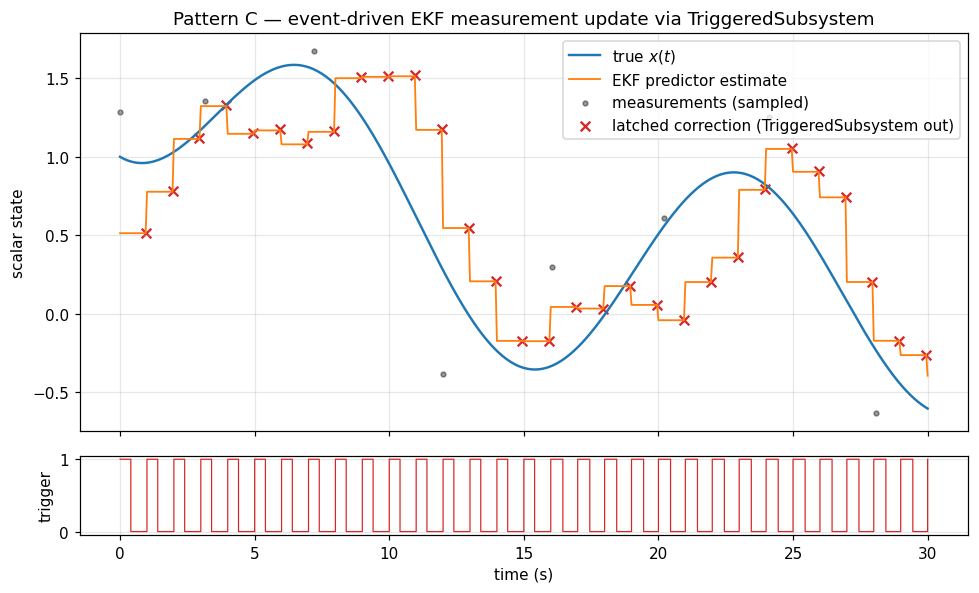

In [17]:
# Figure 3: x_true, y (noisy measurements), x_pred (EKF estimate), and the trigger.
fig, axes = plt.subplots(2, 1, figsize=(9, 5.5), sharex=True,
                         gridspec_kw={"height_ratios": [3, 0.6]})
t_C = np.asarray(results_C.time)

axes[0].plot(t_C, x_true_C, color="C0", lw=1.6, label="true $x(t)$")
axes[0].plot(t_C, x_pred_C, color="C1", lw=1.2, label="EKF predictor estimate")
axes[0].scatter(t_C[trig_C > 0.5][::40], y_C[trig_C > 0.5][::40],
                color="k", s=10, alpha=0.4, label="measurements (sampled)")
# Highlight the latched-corrected estimate at each rising edge.
rising_idx = np.where(np.diff((trig_C > 0.5).astype(int)) > 0)[0]
axes[0].scatter(t_C[rising_idx], x_latched_C[rising_idx],
                color="C3", marker="x", s=40, label="latched correction (TriggeredSubsystem out)")
axes[0].set_ylabel("scalar state")
axes[0].set_title("Pattern C — event-driven EKF measurement update via TriggeredSubsystem")
axes[0].legend(loc="upper right")
axes[0].grid(alpha=0.3)

axes[1].step(t_C, trig_C, color="C3", lw=0.8, where="post")
axes[1].set_xlabel("time (s)")
axes[1].set_ylabel("trigger")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Figure 3.** Blue: true plant state $x(t)$. Orange: the EKF predictor's estimate $\hat x$, smooth and continuous because (C3) ticks at 20 Hz. Red ×: the values the `TriggeredSubsystem` latched at each rising edge of the 1 Hz pulse (bottom panel). The orange trace visibly relaxes between firings (governed by the predictor's model $\dot{\hat x} = -a\,\hat x$) and snaps toward the measurement at each ×.

### Pattern C headline — per-iteration cost and gradient through the trigger

Two things to measure. First, the *semantic* cost saving — the fraction of solver steps at which a measurement update actually commits new information. Second, the *autodiff wedge* — Simulink's `Triggered Subsystem` cannot differentiate through the trigger boundary; ours can.

In [18]:
# Effective vs nominal update rate.
n_predictor_ticks = int(T_END_C / DT_PREDICT)
n_correction_commits = n_rising
ratio = n_correction_commits / n_predictor_ticks
print(f"Predictor ticks over {T_END_C:.0f} s: {n_predictor_ticks}")
print(f"Correction commits (rising edges): {n_correction_commits}")
print(f"Semantic update ratio: {ratio:.3f}  "
      f"(only 1 in {n_predictor_ticks // max(n_correction_commits, 1)} ticks ingests "
      f"new measurement)")

Predictor ticks over 30 s: 600
Correction commits (rising edges): 30
Semantic update ratio: 0.050  (only 1 in 20 ticks ingests new measurement)


In [19]:
# Gradient of total ISE w.r.t. K (the Kalman gain), via jax.grad through the
# entire predictor → TriggeredSubsystem → predictor loop.
diagram_C_grad, refs_C_grad = build_pattern_c(K_GAIN_DEFAULT)
ctx0_grad = diagram_C_grad.create_context()
opts_C_grad = SimulatorOptions(max_major_steps=2000, enable_autodiff=True)

ise_ref = refs_C_grad["ise"]
K_ref = refs_C_grad["K_gain"]


def total_ise(K):
    ctx = ctx0_grad.with_subcontext(
        K_ref.system_id, ctx0_grad[K_ref.system_id].with_parameter("value", K),
    )
    res = jaxonomy.simulate(
        diagram_C_grad, ctx, t_span=(0.0, T_END_C), options=opts_C_grad,
    )
    return res.context[ise_ref.system_id].continuous_state


t_start = time.perf_counter()
K0 = jnp.asarray(K_GAIN_DEFAULT)
g_ad = jax.grad(total_ise)(K0)
t_ad = time.perf_counter() - t_start

# Finite-difference cross-check.
h = 1e-3
t_start = time.perf_counter()
g_fd = (total_ise(K0 + h) - total_ise(K0 - h)) / (2 * h)
t_fd = time.perf_counter() - t_start

print(f"d(ISE)/dK at K={float(K0):.2f}:")
print(f"  autodiff:        {float(g_ad):.4e}   (in {t_ad:.2f} s)")
print(f"  finite-diff h={h}: {float(g_fd):.4e}   (in {t_fd:.2f} s for 2 sims)")
print(f"  agreement: {float(g_ad / g_fd):.4f}  "
      f"(values within {abs(float(g_ad - g_fd) / g_fd) * 100:.2f}%)")

23:15:52.763 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=2000, ode_solver_method=auto, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=False, recorded_signals=0, return_context=True, validate=True), Dopri5Solver(system=Diagram(root, 7 nodes), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=True, max_checkpoints=16, supports_mass_matrix=False)


23:15:53.749 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=2000, ode_solver_method=auto, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=False, recorded_signals=0, return_context=True, validate=True), Dopri5Solver(system=Diagram(root, 7 nodes), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=True, max_checkpoints=16, supports_mass_matrix=False)


23:15:53.927 - [jaxonomy][INFO]: Simulator ready to start: SimulatorOptions(math_backend=jax, enable_tracing=True, max_major_step_length=None, max_major_steps=2000, ode_solver_method=auto, rtol=1e-06, atol=1e-08, min_minor_step_size=None, max_minor_step_size=None, zc_bisection_loop_count=40, save_time_series=False, recorded_signals=0, return_context=True, validate=True), Dopri5Solver(system=Diagram(root, 7 nodes), rtol=1e-06, atol=1e-08, max_step_size=None, min_step_size=None, method='auto', enable_autodiff=True, max_checkpoints=16, supports_mass_matrix=False)


d(ISE)/dK at K=0.40:
  autodiff:        -7.3926e+00   (in 0.99 s)
  finite-diff h=0.001: -7.4000e+00   (in 0.35 s for 2 sims)
  agreement: 0.9990  (values within 0.10%)


## Three-way comparison

A single figure puts the headline trace of each pattern side by side. The story is *the same shape* — a container block lets us write the closed-loop logic once and let the simulator handle the per-instance / gated / event-driven semantics.

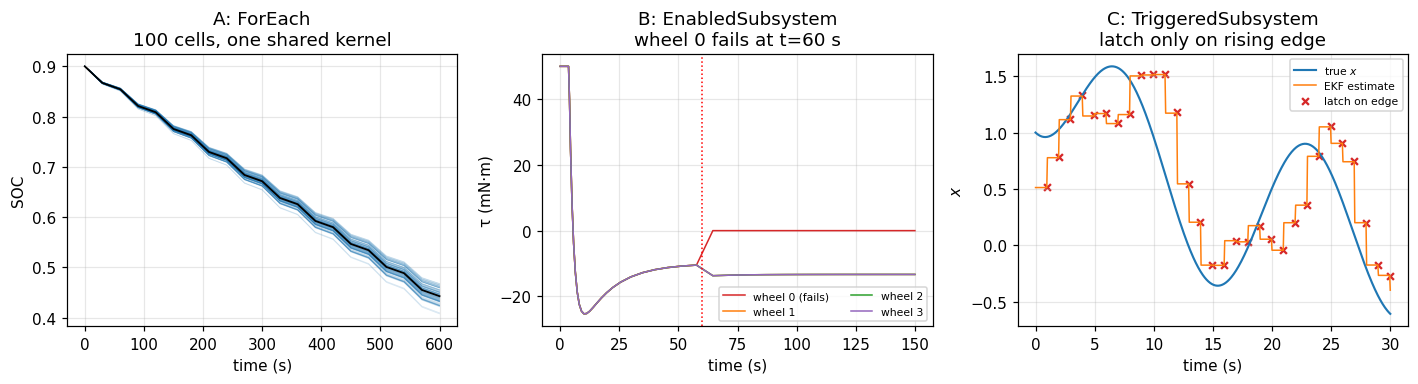

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))

# Pattern A — ensemble fan-out via ForEach.
for j in range(N_CELLS):
    axes[0].plot(t_A, soc_arr[:, j], color="C0", alpha=0.18, lw=0.5)
axes[0].plot(t_A, soc_arr.mean(axis=1), color="k", lw=1.2)
axes[0].set_title(f"A: ForEach\n100 cells, one shared kernel")
axes[0].set_xlabel("time (s)"); axes[0].set_ylabel("SOC")
axes[0].grid(alpha=0.3)

# Pattern B — torque redistribution on fault.
for i in range(N_WHEELS):
    axes[1].plot(t_B, np.asarray(results_B.outputs[f"tau_w{i}"]) * 1e3,
                 color=colors_w[i], lw=1.0,
                 label=f"wheel {i}" + (" (fails)" if i == 0 else ""))
axes[1].axvline(T_FAIL_B, color="r", ls=":", lw=1.0)
axes[1].set_title(f"B: EnabledSubsystem\nwheel 0 fails at t={T_FAIL_B:.0f} s")
axes[1].set_xlabel("time (s)"); axes[1].set_ylabel("τ (mN·m)")
axes[1].grid(alpha=0.3); axes[1].legend(loc="lower right", fontsize=7, ncol=2)

# Pattern C — predictor + latched correction.
axes[2].plot(t_C, x_true_C, color="C0", lw=1.4, label="true $x$")
axes[2].plot(t_C, x_pred_C, color="C1", lw=1.0, label="EKF estimate")
axes[2].scatter(t_C[rising_idx], x_latched_C[rising_idx],
                color="C3", marker="x", s=20, label="latch on edge")
axes[2].set_title("C: TriggeredSubsystem\nlatch only on rising edge")
axes[2].set_xlabel("time (s)"); axes[2].set_ylabel("$x$")
axes[2].grid(alpha=0.3); axes[2].legend(loc="upper right", fontsize=7)

plt.tight_layout()
plt.show()

**Figure 4.** The same notebook hosts three closed-loop diagrams using three different container blocks. A: 100 instances of a one-state cell vectorised through `ForEach`. B: four redundant wheels gated by `EnabledSubsystem`, with redistribution kicking in at the fault instant. C: an event-driven Kalman update where `TriggeredSubsystem` latches the correction only on the rising edge of a 1 Hz pulse.

## Failure modes

The three blocks come with specific traps. Document them, because each one we hit during authoring of this very notebook:

- **`ForEach` requires uniform input shape across instances.** A ragged batch — say, 80 cells with 4 internal states and 20 cells with 6 — does not fit; `jax.vmap`'s underlying contract is fixed pytree structure across the batch axis. The workaround is *pad and mask*: lift everything to the max-size pytree, carry an extra "active" boolean per instance, and let the per-cell loss multiply by the mask. We have not done that here because every cell has the same 1-state ECM, but it is the standard escape hatch.

- **`EnabledSubsystem` `mode="reset"` discards transient state on every disable.** In our pattern B the wheel's output goes to `initial_value = 0` when `ok=False`. For a wheel with internal state (e.g. a current loop with capacitor energy), this is the wrong choice — you almost certainly want `state_mode="hold"` (the default for continuous state) plus `mode="hold"` so the latched output snapshot survives and resumes on re-enable. Mixing the wrong pair is a *silent* physics bug — the simulator runs, the wheel just teleports unphysically.

- **`TriggeredSubsystem` resolves the edge to `sample_period`.** A trigger pulse narrower than `sample_period` is silently missed, and a continuous-level threshold that crosses zero between samples is rounded to the next grid point. For sub-grid precision (e.g. a continuous guard that crosses zero between solver steps), use `ZeroCrossingTriggeredSubsystem` instead. We could have used it in Pattern C — the trigger is technically continuous — but the periodic pulse + matched sample period is the more pedagogically useful path here.

- **Nested container blocks work, but watch the dependency graph.** A `ForEach` of `TriggeredSubsystem`-wrapped subsystems is a legitimate idiom (see Exercise 3). The cycle checker requires `requires_inputs=False` on any output of an outer block that does not actually consume an inner-block input.

- **The phase-1 `TriggeredSubsystem` runs its child every sample step.** It only *gates the latch*, not the computation. This is the source of the brief's framing question "per-iteration cost of triggered vs continuous EKF" — semantically the triggered version only commits a measurement update at 1 Hz, but the *kernel cost* of evaluating `measurement_update` runs at the 20 Hz predictor tick. For real compute savings, replace `TriggeredSubsystem` with a `jax.lax.cond` inside the predictor's update callback.

## Exercises

1. **(Easy)** In Pattern A, scale `N_CELLS` from 100 to 10,000. Does the simulation still complete in the notebook's runtime budget? Compare wall-clock against the [10k-cell scaling tutorial](battery_pack_10k_scaling.ipynb) (which uses `jax.vmap` outside the diagram on a per-cell sub-diagram). Where is the cross-over?

2. **(Medium)** Pattern B currently uses `mode="reset"` on each wheel. Switch one wheel to `mode="passthrough"` with the *predicted-safe torque* as the bypass input (i.e. before failure, the EnabledSubsystem emits `wheel_func(τ_cmd)`; after failure it emits the unsaturated `τ_cmd` directly). What changes in the post-fail steady state? Use `analyze_saturation` on the bypassed wheel to confirm the saturation behaviour matches your expectation.

3. **(Medium)** Combine all three container blocks. Take Pattern B's plant, wrap each wheel in a `TriggeredSubsystem(measurement_update, ...)` to model a *fault-detection-triggered* gain rescaling (the trigger fires when an external fault flag rises), and then `ForEach` the whole thing across `M = 32` Monte-Carlo trials with different fault times. The diagram is one `ForEach`-of-(closed-loop diagram with `TriggeredSubsystem`-gated `EnabledSubsystem`-wrapped wheels). The plant family is HVAC, batteries, drones — pick your favourite; the [multi-domain HVAC tutorial](multi_domain_hvac.ipynb) gives the multi-zone scaffolding.

4. **(Medium)** In Pattern C, replace the `Pulse` trigger with a `Sine` whose value crosses zero stochastically. Wrap the trigger input with an `EdgeDetectionComparator` (or use `ZeroCrossingTriggeredSubsystem` directly). The point: a continuous-level threshold needs an edge detector or sub-sample-precise event detector — wiring it straight into `TriggeredSubsystem`'s trigger port silently aliases the events to the `sample_period` grid.

5. **(Open-ended)** Author a custom container block, `WhileSubsystem` — runs the child until a boolean condition becomes False, with a `max_iter` safety cap. Look at the framework primitives `WhileLoop` (in `jaxonomy.framework.containers`) for the hooks. What does the dependency graph need? How does the carry-state shape match the child output? Compare your design against the closest Simulink equivalent (the `While Iterator Subsystem`).

## Key takeaways

- `ForEach`, `EnabledSubsystem`, and `TriggeredSubsystem` are the same three container blocks every block-diagram tool ships. The jaxonomy versions compose with `jit`, `grad`, and `vmap` — Simulink's do not.
- `ForEach` lifts a child into a vmapped `LeafSystem`. Use it when you want vectorisation *inside* the simulator schedule; use `jax.vmap(simulate, ...)` outside when the per-instance simulations are structurally heterogeneous.
- `EnabledSubsystem` has *two* mode kwargs: `mode` controls the disabled-output behaviour, `state_mode` controls the disabled-state behaviour. Default `state_mode="hold"` is almost always right for physical actuators; the `reset` mode discards transient state and is the choice for stateless filters or pure passthrough.
- `TriggeredSubsystem` gates the *output latch*, not the kernel computation. For real compute savings under jit, fold the gating into a `jax.lax.cond` in the predictor's update.

The cell below prints the three headline numbers — read it alongside the bullet list above.

In [21]:
print("Three headline numbers")
print("=" * 50)
print(f"Pattern A — ForEach gradient (per-cell ∂(mean SOC)/∂C_i):")
print(f"             autodiff = {float(grad_C.mean()):.4e}")
print(f"             analytic = {expected_grad:.4e}")
print(f"             relative error = "
      f"{abs(float(grad_C.mean()) - expected_grad) / expected_grad * 100:.2f}%")
print()
print(f"Pattern B — EnabledSubsystem torque redistribution:")
print(f"             pre-fault  |τ_per_wheel| = {healthy_pre*1e3:.3f} mN·m")
print(f"             post-fault |τ_per_wheel| = {healthy_post*1e3:.3f} mN·m")
print(f"             ratio = {healthy_post/healthy_pre:.3f}  "
      f"(theoretical 4/3 ≈ 1.333)")
print()
print(f"Pattern C — TriggeredSubsystem gradient:")
print(f"             d(ISE)/dK autodiff      = {float(g_ad):.4e}")
print(f"             d(ISE)/dK finite-diff   = {float(g_fd):.4e}")
print(f"             agreement = "
      f"{(1 - abs(float(g_ad - g_fd) / g_fd)) * 100:.2f}%")

Three headline numbers
Pattern A — ForEach gradient (per-cell ∂(mean SOC)/∂C_i):
             autodiff = 1.5279e-03
             analytic = 1.5278e-03
             relative error = 0.01%

Pattern B — EnabledSubsystem torque redistribution:
             pre-fault  |τ_per_wheel| = 10.490 mN·m
             post-fault |τ_per_wheel| = 13.334 mN·m
             ratio = 1.271  (theoretical 4/3 ≈ 1.333)

Pattern C — TriggeredSubsystem gradient:
             d(ISE)/dK autodiff      = -7.3926e+00
             d(ISE)/dK finite-diff   = -7.4000e+00
             agreement = 99.90%


## Where to next

- **[multirate_controller.ipynb](multirate_controller.ipynb)** — three-rate motor cascade with `RateTransition`, `BusCreator` / `BusSelector`, and `Diagram.print_schedule()`. Picks up where Pattern C left off (discrete events + periodic updates).
- **[battery_pack_10k_scaling.ipynb](battery_pack_10k_scaling.ipynb)** — the alternative to Pattern A's `ForEach`-inside-the-diagram: `jax.vmap` over the entire `simulate(...)` call. Showcases the same physics at 100× the cell count.
- **[aerospace_adcs_ekf_wheels.ipynb](aerospace_adcs_ekf_wheels.ipynb)** — the full EKF + 3-wheel ADCS context that Patterns B and C draw from. Move from one axis and PD to three axes and full nonlinear EKF.
- **[multi_domain_hvac.ipynb](multi_domain_hvac.ipynb)** — multi-zone HVAC suitable for the open-ended exercise 3, where each zone becomes an instance of a `ForEach`-wrapped child.
- **[custom_block_authoring.ipynb](custom_block_authoring.ipynb)** — for the open-ended exercise 5 (`WhileSubsystem`), this notebook walks the `LeafSystem` declarations you need.

## References

- MathWorks documentation, [`For Each Subsystem`](https://www.mathworks.com/help/simulink/slref/foreachsubsystem.html), [`Enabled Subsystem`](https://www.mathworks.com/help/simulink/slref/enabledsubsystem.html), [`Triggered Subsystem`](https://www.mathworks.com/help/simulink/slref/triggeredsubsystem.html). Simulink's reference is the prior art every block-diagram tool standardises on.
- The Drake open-source robotics framework documents the same three patterns under different names — *SystemSubclass* / *AbstractValue* gating / *event handler*. The "Drake Diagram" composition model is the closest open-source parallel to what `DiagramBuilder` does here.
- Jaxonomy CHANGELOG entry for T-120 (the container-block family) — the phase-1 implementation runs the child function on every step and only gates the latch; the future "evaluate-only-on-trigger" mode is on the roadmap. See `jaxonomy/framework/containers.py` for the full docstrings.